# Resale Transaction Prices of HDB Flats in Singapore since 2017

```
Dataset: Resale flat prices based on registration date from Jan-2017 onwards
Agency: HDB
Coverage: January 2017–July 2026
Size: about 235,600 transactions, 22.2 MB
Last updated: August 2026 according to the current data.gov.sg page.
```

## Can we predict the resale price of an HDB flat from its characteristics, location, floor area, lease information and transaction month?

## Step 1: Import Libraries

In [2]:
from pathlib import Path
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost is required for Part 3. Install it with: pip install xgboost"
    ) from exc

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42
PRIMARY_COLOR = "#2C7FB8"

## Step 2: Load Dataset

In [3]:
df = pd.read_csv('resale_2017.csv')

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 238326
Columns: 11


In [5]:
df.columns.tolist()

['month',
 'town',
 'flat_type',
 'block',
 'street_name',
 'storey_range',
 'floor_area_sqm',
 'flat_model',
 'lease_commence_date',
 'remaining_lease',
 'resale_price']

# Step 3: Understand the dataset

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238326 entries, 0 to 238325
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                238326 non-null  object 
 1   town                 238326 non-null  object 
 2   flat_type            238326 non-null  object 
 3   block                238326 non-null  object 
 4   street_name          238326 non-null  object 
 5   storey_range         238326 non-null  object 
 6   floor_area_sqm       238326 non-null  float64
 7   flat_model           238326 non-null  object 
 8   lease_commence_date  238326 non-null  int64  
 9   remaining_lease      238326 non-null  object 
 10  resale_price         238326 non-null  float64
dtypes: float64(2), int64(1), object(8)
memory usage: 20.0+ MB


## Step 4: Check for Duplicates

In [7]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage duplicated:", duplicate_count / len(df) * 100)

Number of duplicate rows: 317
Percentage duplicated: 0.13301108565578243


In [8]:
# check if rows are exact duplicate
df[df.duplicated(keep=False)]

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price
224,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.00,Improved,1975,57 years,"470,000.00"
243,2017-01,BUKIT MERAH,4 ROOM,106,HENDERSON CRES,07 TO 09,81.00,Improved,1975,57 years,"470,000.00"
304,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.00,Improved,1979,61 years 02 months,"470,000.00"
305,2017-01,CENTRAL AREA,3 ROOM,271,QUEEN ST,16 TO 18,68.00,Improved,1979,61 years 02 months,"470,000.00"
505,2017-01,JURONG EAST,4 ROOM,265,TOH GUAN RD,04 TO 06,101.00,Model A,1998,80 years 09 months,"470,000.00"
...,...,...,...,...,...,...,...,...,...,...,...
233613,2026-03,SENGKANG,5 ROOM,224C,COMPASSVALE WALK,07 TO 09,121.00,Improved,1999,72 years 01 month,"680,000.00"
235760,2026-03,TOA PAYOH,4 ROOM,103B,BIDADARI PK DR,07 TO 09,93.00,Model A,2021,94 years 04 months,"1,095,000.00"
235763,2026-03,TOA PAYOH,4 ROOM,103B,BIDADARI PK DR,07 TO 09,93.00,Model A,2021,94 years 04 months,"1,095,000.00"
236187,2026-04,WOODLANDS,3 ROOM,148,WOODLANDS ST 13,01 TO 03,68.00,New Generation,1985,57 years 11 months,"385,000.00"


In [9]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)
print("Percentage duplicated:", duplicate_count / len(df) * 100)

Number of duplicate rows: 317
Percentage duplicated: 0.13301108565578243


In [10]:
# drop duplicated rows
df = df.drop_duplicates().copy()

In [11]:
print("Rows after removing duplicates:", len(df))

Rows after removing duplicates: 238009


Duplicate transactions could artificially increase the frequency of certain observations and distort:

- distributions
- averages
- correlations
- model training

## Step 5: Check for missing values

In [12]:
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Missing %": df.isna().mean() * 100
})

missing

,Missing,Missing %
month,0,0.00
town,0,0.00
flat_type,0,0.00
block,0,0.00
street_name,0,0.00
storey_range,0,0.00
floor_area_sqm,0,0.00
flat_model,0,0.00
lease_commence_date,0,0.00
remaining_lease,0,0.00


There are no missing values in any of the 11 columns.

That's useful because we don't need to perform arbitrary imputation during our initial cleaning.

However, we'll still build an imputation step into the eventual ML pipeline because it is good practice for a production-style model.

## Step 6 — Check data types and convert dates

In [13]:
df["month"] = pd.to_datetime(
    df["month"],
    format="%Y-%m",
    errors="coerce"
)

In [14]:
df["month"].min(), df["month"].max()

(Timestamp('2017-01-01 00:00:00'), Timestamp('2026-08-01 00:00:00'))

In [15]:
# create time-related variables:
df["transaction_year"] = df["month"].dt.year
df["transaction_month"] = df["month"].dt.month
df["transaction_quarter"] = df["month"].dt.quarter

In [16]:
# Check a sample to see if the new variables are extracted accurately
df[
    ["month", "transaction_year",
     "transaction_month", "transaction_quarter"]
].sample(5)

,month,transaction_year,transaction_month,transaction_quarter
15510,2017-10-01,2017,10,4
165377,2023-01-01,2023,1,1
214738,2025-12-01,2025,12,4
44585,2019-02-01,2019,2,1
23462,2018-03-01,2018,3,1


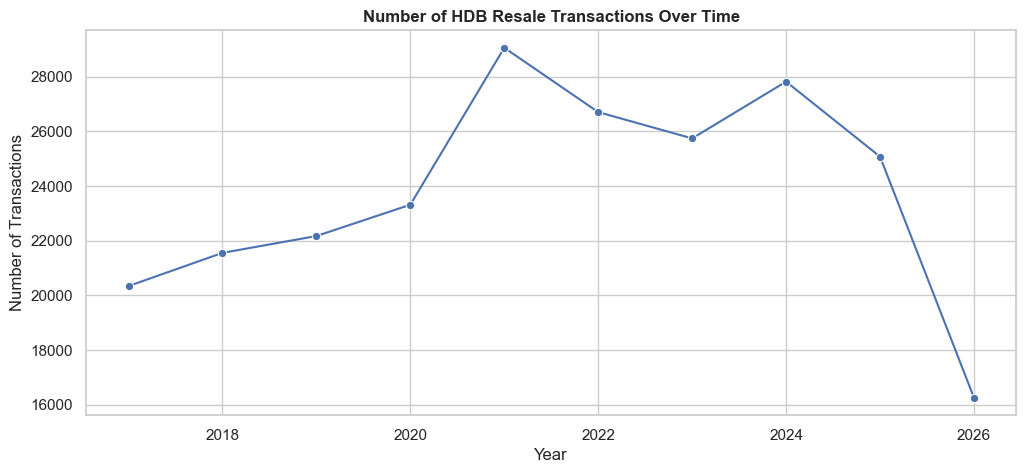

In [17]:
# Visualise the transaction volume:
yearly_transactions = (
    df.groupby("transaction_year")
      .size()
      .reset_index(name="transactions")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=yearly_transactions,
    x="transaction_year",
    y="transactions",
    marker="o"
)

plt.title("Number of HDB Resale Transactions Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.show()

What this tells us

This helps establish whether our dataset has:

- consistent transaction volume
- unusual periods
- structural changes
- enough historical observations

It will also help justify our later time-based train/test split.

## Step 7. Understand the target variable

In [18]:
df["resale_price"].describe()

count     238,009.00
mean      533,830.01
std       191,734.27
min       140,000.00
25%       390,000.00
50%       500,800.00
75%       640,000.00
max     1,728,000.00
Name: resale_price, dtype: float64

The mean is considerably higher than the median, suggesting a right-skewed distribution.

In [19]:
print(
    "Skewness:",
    df["resale_price"].skew()
)

Skewness: 0.9694098041142271


That's substantial enough to be aware of during modelling.

## Step 8. Visualise resale-price distribution

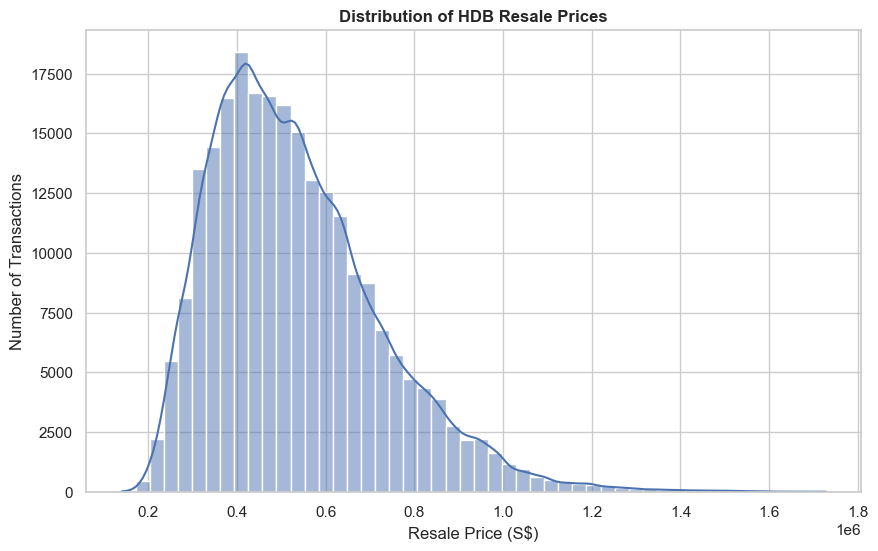

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    x=df["resale_price"],
    bins=50,
    kde=True
)

plt.title("Distribution of HDB Resale Prices")
plt.xlabel("Resale Price (S$)")
plt.ylabel("Number of Transactions")

plt.show()

The distribution is positively skewed because a relatively small number of expensive flats pull the upper tail upward.

This matters for machine learning because:

`Models may make larger errors on high-priced properties.`

### 8.1. How has the HDB market changed over time?

In [21]:
yearly_price = (
    df.groupby("transaction_year")["resale_price"]
      .agg(["mean", "median", "count"])
      .reset_index()
)

yearly_price

,transaction_year,mean,median,count
0,2017,"443,743.44","410,000.00",20337
1,2018,"441,310.44","408,000.00",21552
2,2019,"432,180.07","400,000.00",22168
3,2020,"452,312.74","425,000.00",23313
4,2021,"511,417.39","483,000.00",29057
5,2022,"549,701.07","525,000.00",26702
6,2023,"571,814.76","550,000.00",25740
7,2024,"612,597.98","590,000.00",27817
8,2025,"652,509.23","628,000.00",25072
9,2026,"660,774.44","630,000.00",16251


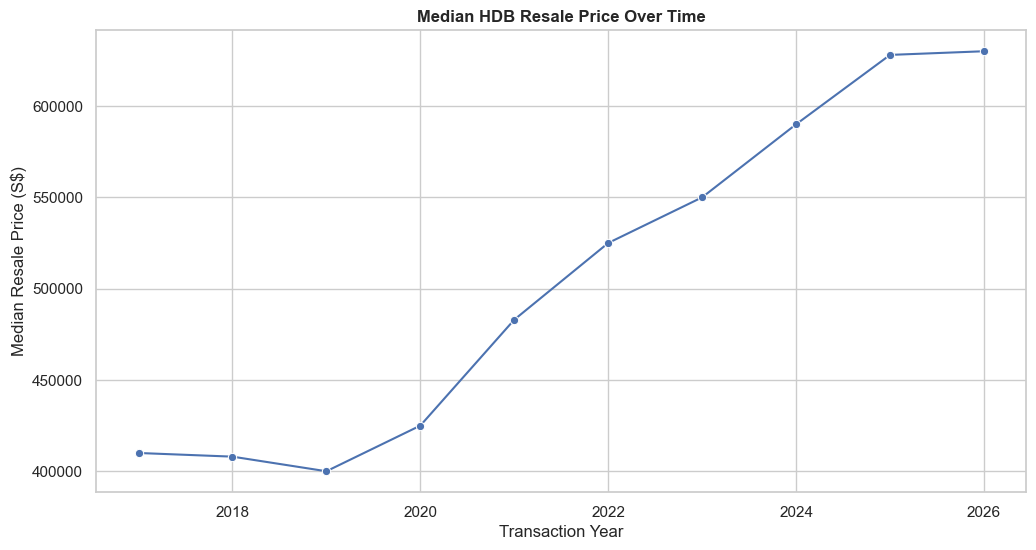

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_price,
    x="transaction_year",
    y="median",
    marker="o"
)

plt.title("Median HDB Resale Price Over Time")
plt.xlabel("Transaction Year")
plt.ylabel("Median Resale Price (S$)")

plt.show()

This is a very strong EDA finding:

- `Median HDB resale prices increased from approximately S$410,000 in 2017 to S$630,000 in 2026.`

That's roughly a 54% increase in the median transaction price.

More importantly for ML:

`transaction_year` is likely to be an important predictor.

### 8.2. Does flat size affect resale price?

In [23]:
df["floor_area_sqm"].describe()

count   238,009.00
mean         96.69
std          24.02
min          31.00
25%          81.00
50%          93.00
75%         112.00
max         366.70
Name: floor_area_sqm, dtype: float64

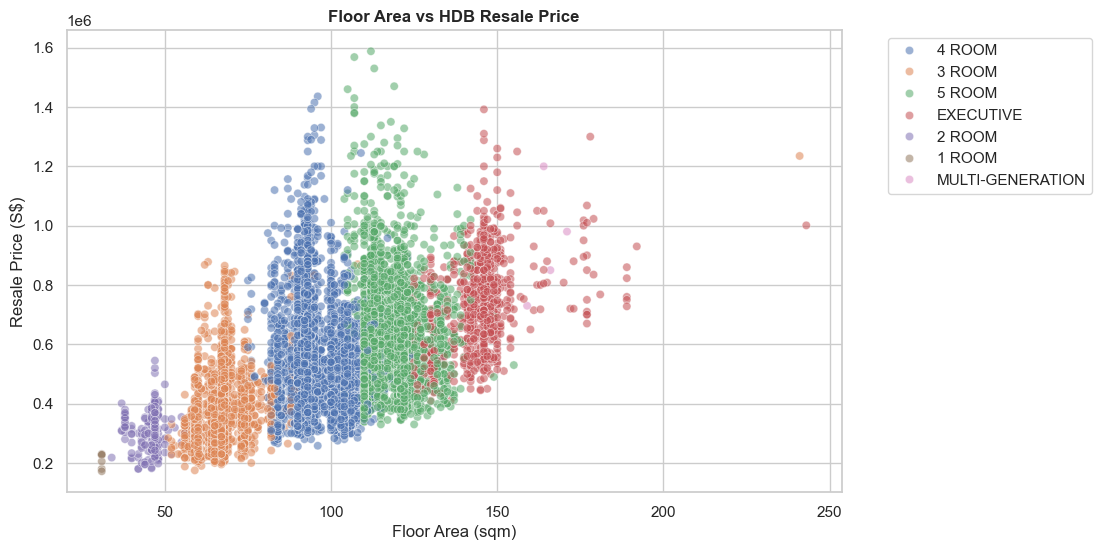

In [24]:
sample = df.sample(
    10000,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample,
    x="floor_area_sqm",
    y="resale_price",
    hue='flat_type',
    alpha=0.55
)

my_order = ["1 ROOM", "2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "MULTI-GENERATION", "EXECUTIVE"]

plt.title("Floor Area vs HDB Resale Price")
plt.xlabel("Floor Area (sqm)")
plt.ylabel("Resale Price (S$)")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.show()

In [25]:
df[
    ["floor_area_sqm", "resale_price"]
].corr()

,floor_area_sqm,resale_price
floor_area_sqm,1.00,0.56
resale_price,0.56,1.00


<b>Finding</b>

There is a clear positive relationship:

- `Larger flats generally command higher resale prices.`

But the relationship isn't perfect, which tells us that other factors such as location, flat type, storey and lease also matter.

### 8.3 Does flat type matter?

In [26]:
df["flat_type"].value_counts()

flat_type
4 ROOM              101077
5 ROOM               58235
3 ROOM               56619
EXECUTIVE            16910
2 ROOM                4994
MULTI-GENERATION        88
1 ROOM                  86
Name: count, dtype: int64

In [27]:
flat_type_price = (
    df.groupby("flat_type")["resale_price"]
      .median()
      .sort_values(ascending=False)
)

flat_type_price

flat_type
MULTI-GENERATION   846,500.00
EXECUTIVE          725,000.00
5 ROOM             610,000.00
4 ROOM             510,000.00
3 ROOM             360,000.00
2 ROOM             312,000.00
1 ROOM             212,500.00
Name: resale_price, dtype: float64

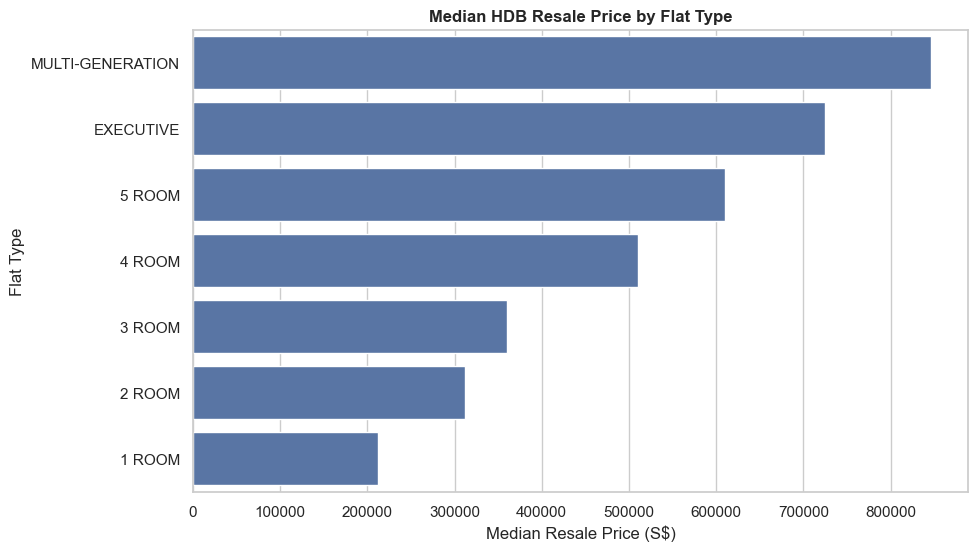

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=flat_type_price.values,
    y=flat_type_price.index
)

plt.title("Median HDB Resale Price by Flat Type")
plt.xlabel("Median Resale Price (S$)")
plt.ylabel("Flat Type")

plt.show()

<b>Finding</b>

This is one of the clearest relationships in the dataset:

- `Larger/higher-category flats tend to have substantially higher resale prices.`

`flat_type` should definitely be considered as an ML feature.

### 8.4 Does location matter?

The dataset contains 26 towns, making town a useful categorical variable.

In [29]:
town_price = (
    df.groupby("town")["resale_price"]
      .agg(["median", "mean", "count"])
      .sort_values("median", ascending=False)
)

town_price

,median,mean,count
town,,,
BUKIT TIMAH,"783,000.00","788,395.51",577
BISHAN,"699,000.00","717,441.47",4137
QUEENSTOWN,"670,800.00","649,939.52",6511
BUKIT MERAH,"660,000.00","645,680.45",9070
PASIR RIS,"580,000.00","594,627.88",6889
CENTRAL AREA,"575,000.00","701,923.13",1844
KALLANG/WHAMPOA,"570,000.00","600,733.22",7254
TAMPINES,"550,000.00","573,040.71",16473
PUNGGOL,"535,000.00","550,329.36",17214


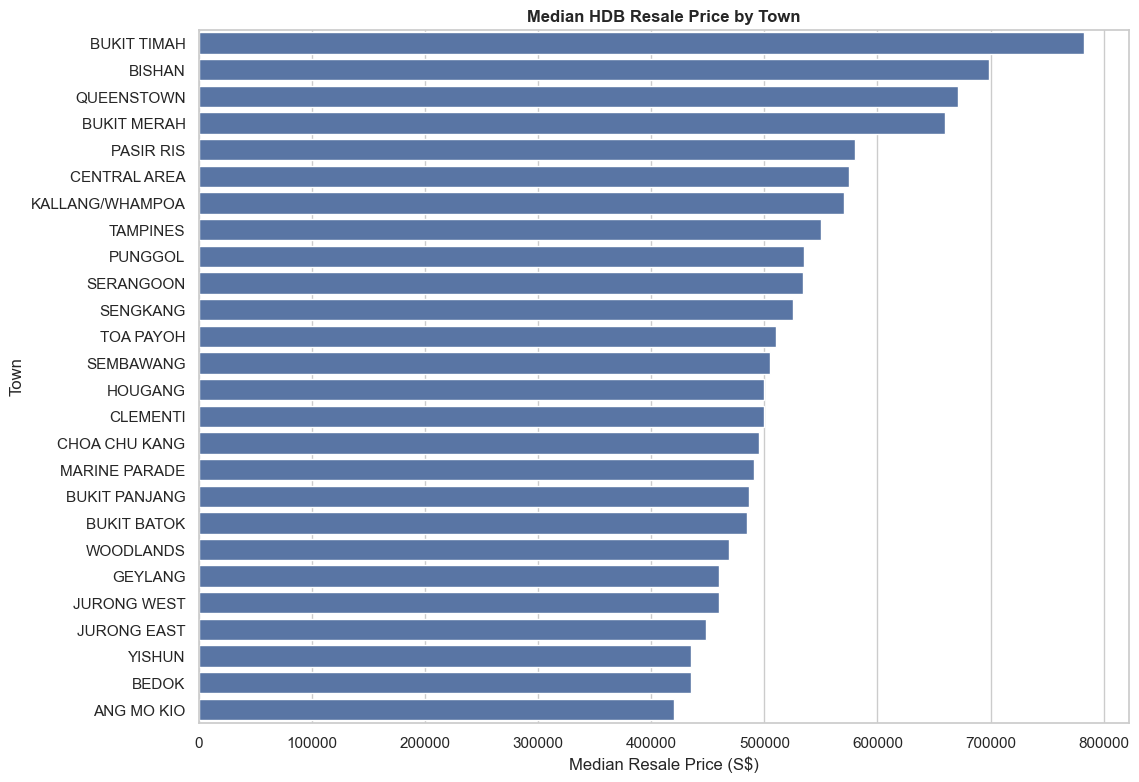

In [30]:
plt.figure(figsize=(12, 9))

sns.barplot(
    data=town_price.reset_index(),
    x="median",
    y="town"
)

plt.title("Median HDB Resale Price by Town")
plt.xlabel("Median Resale Price (S$)")
plt.ylabel("Town")

plt.show()

<b>Finding</b>

There's a substantial location effect.

That tells us:

- `Where a flat is located appears to be an important determinant of its resale price.`

So `town` should definitely be retained.

### 8.5 A better way to examine location

Raw resale price can be misleading because larger flats tend to cost more.

In [31]:
df["price_per_sqm"] = (
    df["resale_price"] /
    df["floor_area_sqm"]
)

In [32]:
town_psm = (
    df.groupby("town")["price_per_sqm"]
      .median()
      .sort_values(ascending=False)
)

town_psm

town
CENTRAL AREA      7,699.10
QUEENSTOWN        7,523.08
BUKIT MERAH       6,967.21
BUKIT TIMAH       6,780.82
BISHAN            6,407.77
MARINE PARADE     6,338.46
KALLANG/WHAMPOA   6,270.59
TOA PAYOH         5,783.78
CLEMENTI          5,782.46
PUNGGOL           5,727.27
GEYLANG           5,648.89
SERANGOON         5,627.07
TAMPINES          5,359.38
BUKIT BATOK       5,332.00
SENGKANG          5,304.35
SEMBAWANG         5,276.91
ANG MO KIO        5,271.00
HOUGANG           5,234.38
BEDOK             5,149.58
BUKIT PANJANG     4,917.36
JURONG EAST       4,905.66
YISHUN            4,903.85
PASIR RIS         4,896.55
CHOA CHU KANG     4,705.88
WOODLANDS         4,619.57
JURONG WEST       4,586.78
Name: price_per_sqm, dtype: float64

<mark>Note: Important ML warning</mark>

`price_per_sqm` is excellent for EDA.

But it must NOT be used as a predictor later:

`price_per_sqm
    =
resale_price / floor_area_sqm`

It contains the answer we're trying to predict.

That would create `target leakage`.

### 8.6 Does storey level matter? 

The existing storey_range is categorical text like:

```
01 TO 03
04 TO 06
07 TO 09
...
```

In [33]:
storey_split = (
    df["storey_range"]
    .str.extract(r"(\d+)\s+TO\s+(\d+)")
)

df["storey_midpoint"] = (
    storey_split[0].astype(float) +
    storey_split[1].astype(float)
) / 2

In [34]:
storey_price = (
    df.groupby("storey_midpoint")["resale_price"]
      .median()
)

storey_price

storey_midpoint
2.00      453,000.00
5.00      475,000.00
8.00      490,000.00
11.00     505,000.00
14.00     550,000.00
17.00     590,000.00
20.00     678,444.00
23.00     710,000.00
26.00     768,000.00
29.00     856,000.00
32.00     900,000.00
35.00     901,000.00
38.00     920,000.00
41.00     980,000.00
44.00   1,120,000.00
47.00   1,124,000.00
50.00   1,228,000.00
Name: resale_price, dtype: float64

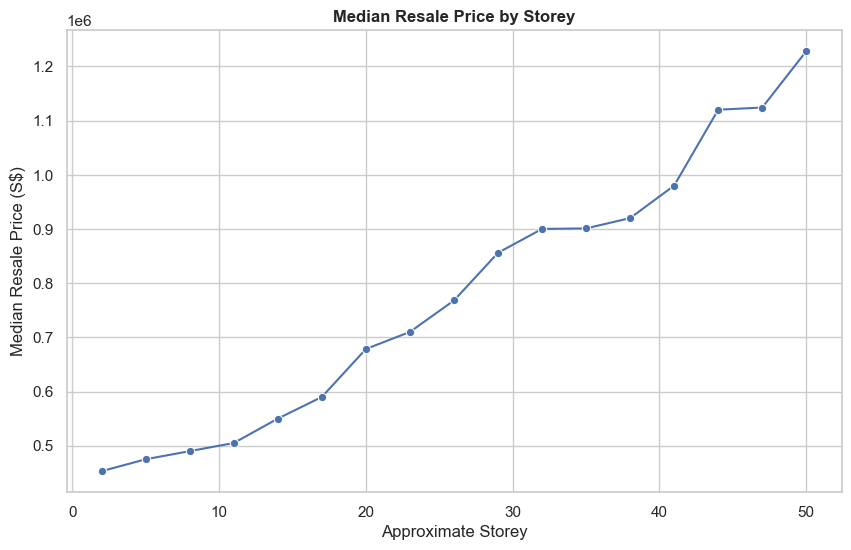

In [35]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=storey_price.reset_index(),
    x="storey_midpoint",
    y="resale_price",
    marker="o"
)

plt.title("Median Resale Price by Storey")
plt.xlabel("Approximate Storey")
plt.ylabel("Median Resale Price (S$)")

plt.show()

<b>Finding</b>

This is a particularly interesting finding:

`Higher-storey flats in this dataset tend to command substantially higher resale prices.`

The median price rises from around `S$453k` at the lowest storey band to above `S$1.2m` at the highest band.

But don't interpret this as "being on the 50th floor causes a flat to be worth S$1.2m."

Higher-storey flats are also likely associated with:

- newer developments
- particular towns
- premium projects
- specific flat models
- larger flats

Machine learning can account for several of these factors simultaneously.

### 8.7 Calculate flat age

In [36]:
df["flat_age_at_sale"] = (
    df["transaction_year"] -
    df["lease_commence_date"]
)

In [37]:
df["flat_age_at_sale"].describe()

count   238,009.00
mean         24.95
std          14.29
min           1.00
25%          11.00
50%          25.00
75%          37.00
max          60.00
Name: flat_age_at_sale, dtype: float64

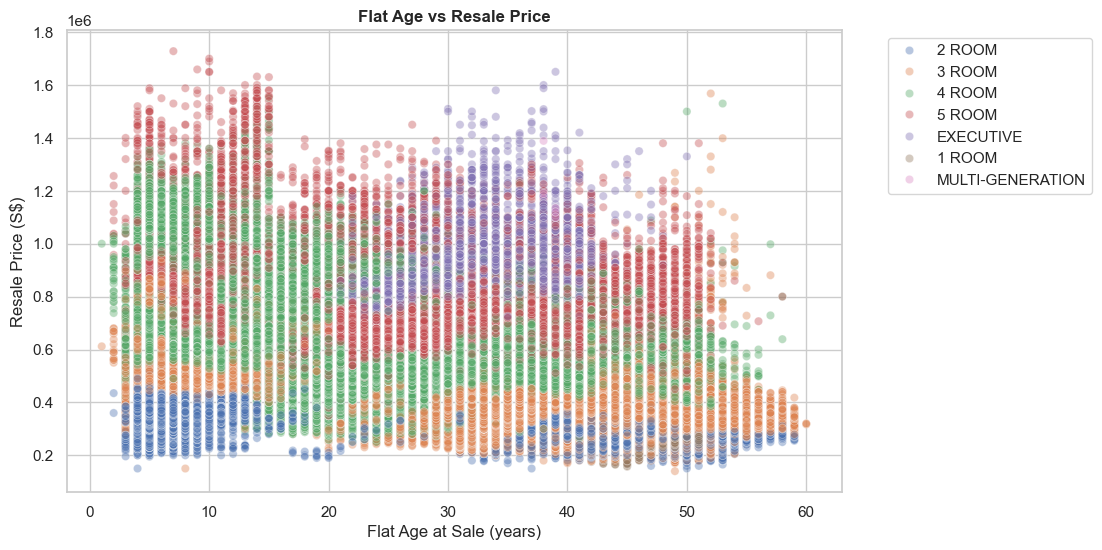

In [38]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="flat_age_at_sale",
    y="resale_price",
    hue='flat_type',
    alpha=0.4
)

plt.title("Flat Age vs Resale Price")
plt.xlabel("Flat Age at Sale (years)")
plt.ylabel("Resale Price (S$)")
plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')

plt.show()

In [39]:
df[
    ["flat_age_at_sale", "resale_price"]
].corr()

,flat_age_at_sale,resale_price
flat_age_at_sale,1.00,-0.30
resale_price,-0.30,1.00


<b>Finding</b>

There is a moderate negative relationship:

Older flats generally tend to have lower resale prices, although age clearly isn't the only factor determining price.

### 8.8 Remaining lease

In [40]:
# Currently, remaining_lease is stored as text. We have to transform it as below:
import re
def convert_remaining_lease(value):
    match = re.match(
        r"(\d+)\s+years?\s+(\d+)\s+months?",
        str(value)
    )

    if match:
        years = int(match.group(1))
        months = int(match.group(2))

        return years + months / 12 # in months format

    return np.nan


df["remaining_lease_years"] = (
    df["remaining_lease"]
      .apply(convert_remaining_lease)
)

In [41]:
df["remaining_lease_years"].describe()

count   218,478.00
mean         74.08
std          14.31
min          39.33
25%          62.25
50%          73.75
75%          88.50
max          97.75
Name: remaining_lease_years, dtype: float64

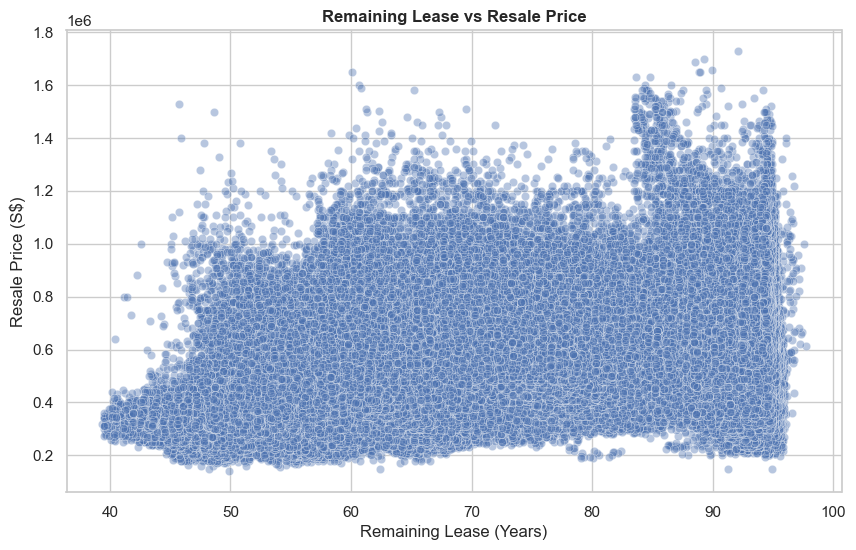

In [42]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="remaining_lease_years",
    y="resale_price",
    alpha=0.4
)

plt.title("Remaining Lease vs Resale Price")
plt.xlabel("Remaining Lease (Years)")
plt.ylabel("Resale Price (S$)")

plt.show()

In [43]:
df[
    ["remaining_lease_years", "resale_price"]
].corr()

,remaining_lease_years,resale_price
remaining_lease_years,1.00,0.30
resale_price,0.30,1.00


<b>Finding</b>

Flats with longer remaining leases generally have higher resale prices.

In this case, `flat_age_at_sale` and `remaining_lease_years` represent related concepts. We should further examine their relationship before deciding whether to use both in the final model or to only use one if they overlap in terms of derivative value.

### 8.9 Numerical correlation overview

Now we combine our engineered numerical features together:

In [44]:
numeric_features_for_eda = [
    "resale_price",
    "floor_area_sqm",
    "lease_commence_date",
    "transaction_year",
    "storey_midpoint",
    "flat_age_at_sale",
    "remaining_lease_years"
]

correlation = (
    df[numeric_features_for_eda]
      .corr()["resale_price"]
      .sort_values(ascending=False)
)

correlation

resale_price             1.00
floor_area_sqm           0.56
transaction_year         0.41
lease_commence_date      0.38
storey_midpoint          0.34
remaining_lease_years    0.30
flat_age_at_sale        -0.30
Name: resale_price, dtype: float64

### 8.10 Investigate town × flat type

In [45]:
town_flat_price = pd.pivot_table(
    df,
    values="resale_price",
    index="town",
    columns="flat_type",
    aggfunc="median"
)

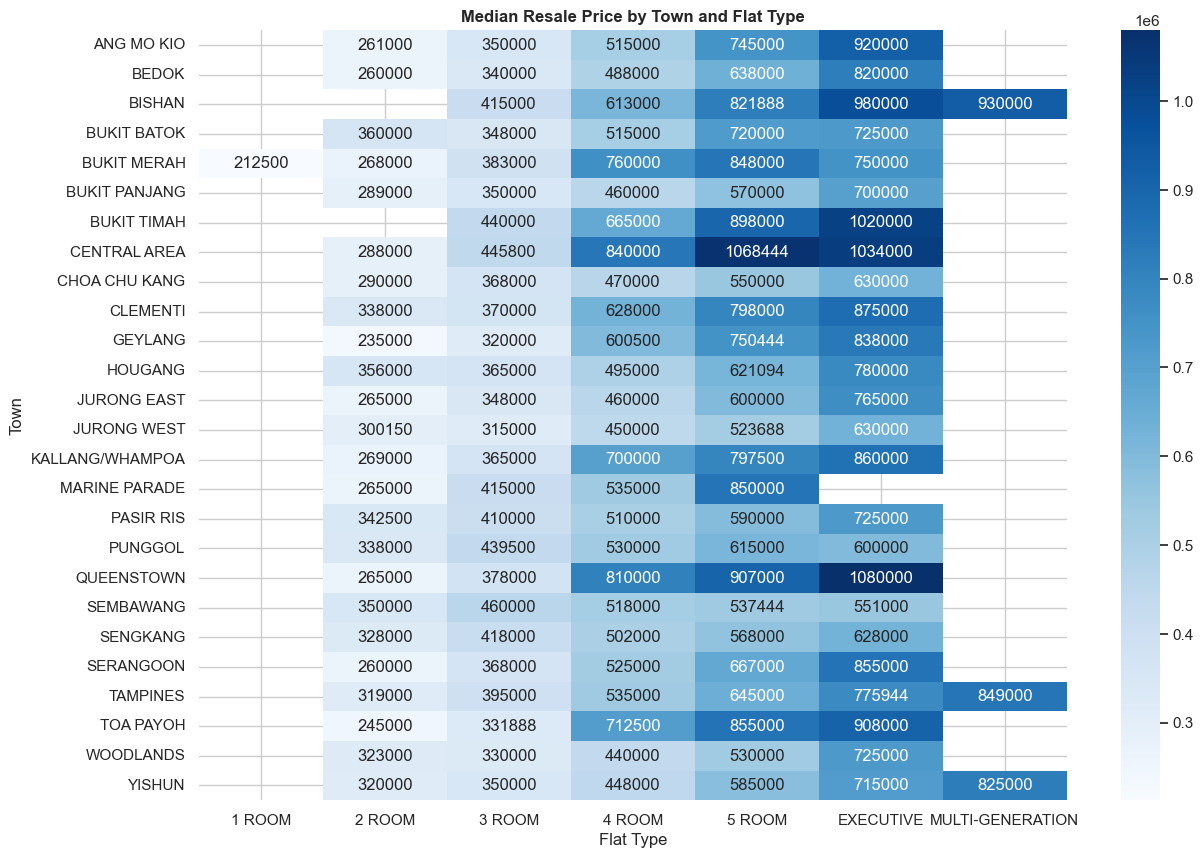

In [46]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    town_flat_price,
    annot=True,
    fmt=".0f",
    cmap="Blues"
)

plt.title("Median Resale Price by Town and Flat Type")
plt.xlabel("Flat Type")
plt.ylabel("Town")

plt.show()

This is a very good visualisation for your presentation because it shows that price is not driven by a single variable.

For example:

- `A 4-room flat in one town can have a very different median price from a 4-room flat in another town.`

That interaction is precisely the kind of pattern that a nonlinear ML model can learn.

The heatmap demonstrates why a multivariable model is necessary: the value associated with a flat type differs materially across towns. XGBoost and Random Forest can learn these interactions directly, whereas Linear Regression relies mainly on additive effects unless explicit interaction terms are engineered.

## 9. Outlier Analysis
Using the traditional IQR rule:

In [47]:
q1 = df["resale_price"].quantile(0.25)
q3 = df["resale_price"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_outlier_mask = (
    (df["resale_price"] < lower_bound)
    | (df["resale_price"] > upper_bound)
)

print(f"IQR lower bound: S${lower_bound:,.0f}")
print(f"IQR upper bound: S${upper_bound:,.0f}")
print(f"Potential statistical outliers: {price_outlier_mask.sum():,}")
print(f"Outlier share: {price_outlier_mask.mean():.2%}")

IQR lower bound: S$15,000
IQR upper bound: S$1,015,000
Potential statistical outliers: 4,483
Outlier share: 1.88%


In [48]:
# Finding the 10 most expensive records:
df.nlargest(
    10,
    "resale_price"
)[[
    "town",
    "flat_type",
    "floor_area_sqm",
    "storey_range",
    "flat_model",
    "lease_commence_date",
    "remaining_lease",
    "resale_price"
]]

,town,flat_type,floor_area_sqm,storey_range,flat_model,lease_commence_date,remaining_lease,resale_price
225202,BUKIT MERAH,5 ROOM,113.00,46 TO 48,Improved,2019,92 years 01 month,"1,728,000.00"
232108,QUEENSTOWN,5 ROOM,122.00,19 TO 21,Premium Apartment Loft,2016,89 years 03 months,"1,700,000.00"
225175,BUKIT MERAH,5 ROOM,112.00,28 TO 30,Improved,2016,88 years 06 months,"1,688,888.00"
212074,QUEENSTOWN,5 ROOM,122.00,22 TO 24,Premium Apartment Loft,2016,89 years 11 months,"1,658,888.00"
223706,BISHAN,EXECUTIVE,162.00,22 TO 24,Maisonette,1987,60 years 01 month,"1,650,000.00"
232112,QUEENSTOWN,5 ROOM,122.00,04 TO 06,Premium Apartment Loft,2016,88 years 11 months,"1,650,000.00"
225172,BUKIT MERAH,5 ROOM,112.00,25 TO 27,Improved,2016,88 years 10 months,"1,648,888.00"
199476,BISHAN,5 ROOM,120.00,34 TO 36,DBSS,2011,84 years 10 months,"1,632,000.00"
225944,CENTRAL AREA,5 ROOM,105.00,43 TO 45,Type S2,2011,83 years 08 months,"1,630,000.00"
199498,BISHAN,EXECUTIVE,163.00,22 TO 24,Maisonette,1987,60 years 08 months,"1,600,000.00"


and it is a genuine-looking 5-room flat in Bukit Merah with a relatively recent lease commencement and high-floor location.

This strongly suggests that <b>at least some of the statistical outliers are legitimate premium transactions rather than data-entry errors.</b>

Therefore:

- `Retain legitimate high-value transactions.`

## 10. Validate impossible values
This is more important than simply removing statistical outliers.

In [49]:
checks = {
    "Resale price <= 0":
        (df["resale_price"] <= 0).sum(),

    "Floor area <= 0":
        (df["floor_area_sqm"] <= 0).sum(),

    "Negative flat age":
        (df["flat_age_at_sale"] < 0).sum(),

    "Lease starts after transaction":
        (df["lease_commence_date"] >
         df["transaction_year"]).sum()
}

pd.Series(checks)

Resale price <= 0                 0
Floor area <= 0                   0
Negative flat age                 0
Lease starts after transaction    0
dtype: int64

#### Now that we have ensured the dataset is cleaned, let's reassign the dataset into a new dataframe to perform ML operations on it

In [50]:
df_cleaned = df.copy()

In [51]:
df_cleaned.shape

(238009, 18)

In [52]:
df_cleaned.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,remaining_lease,resale_price,transaction_year,transaction_month,transaction_quarter,price_per_sqm,storey_midpoint,flat_age_at_sale,remaining_lease_years
0,2017-01-01,ANG MO KIO,2 ROOM,406,ANG MO KIO AVE 10,10 TO 12,44.00,Improved,1979,61 years 04 months,"232,000.00",2017,1,1,"5,272.73",11.00,38,61.33
1,2017-01-01,ANG MO KIO,3 ROOM,108,ANG MO KIO AVE 4,01 TO 03,67.00,New Generation,1978,60 years 07 months,"250,000.00",2017,1,1,"3,731.34",2.00,39,60.58
2,2017-01-01,ANG MO KIO,3 ROOM,602,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"262,000.00",2017,1,1,"3,910.45",2.00,37,62.42
3,2017-01-01,ANG MO KIO,3 ROOM,465,ANG MO KIO AVE 10,04 TO 06,68.00,New Generation,1980,62 years 01 month,"265,000.00",2017,1,1,"3,897.06",5.00,37,62.08
4,2017-01-01,ANG MO KIO,3 ROOM,601,ANG MO KIO AVE 5,01 TO 03,67.00,New Generation,1980,62 years 05 months,"265,000.00",2017,1,1,"3,955.22",2.00,37,62.42


# 11. Decide the target / predictor variables for ML

In [53]:
features = [
    "town",
    "flat_type",
    "flat_model",
    "floor_area_sqm",
    "storey_midpoint",
    "remaining_lease_years",
    "transaction_year",
    "transaction_month",
]

# We are not using price_per_sqm as a feature as it contains the target variable directly. 
# This is to avoid a potential leakage from aggregate features

target = "resale_price"

categorical_features = ["town", "flat_type", "flat_model"]
numeric_features = [
    "floor_area_sqm",
    "storey_midpoint",
    "remaining_lease_years",
    "transaction_year",
    "transaction_month",
]

model_df = df_cleaned[["month"] + features + [target]].copy()
X = model_df[features].copy()
y = model_df[target].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Categorical features:", categorical_features)
print("Numerical features:", numeric_features)
X.head()

X shape: (238009, 8)
y shape: (238009,)
Categorical features: ['town', 'flat_type', 'flat_model']
Numerical features: ['floor_area_sqm', 'storey_midpoint', 'remaining_lease_years', 'transaction_year', 'transaction_month']


,town,flat_type,flat_model,floor_area_sqm,storey_midpoint,remaining_lease_years,transaction_year,transaction_month
0,ANG MO KIO,2 ROOM,Improved,44.00,11.00,61.33,2017,1
1,ANG MO KIO,3 ROOM,New Generation,67.00,2.00,60.58,2017,1
2,ANG MO KIO,3 ROOM,New Generation,67.00,2.00,62.42,2017,1
3,ANG MO KIO,3 ROOM,New Generation,68.00,5.00,62.08,2017,1
4,ANG MO KIO,3 ROOM,New Generation,67.00,2.00,62.42,2017,1


### NOTE: 

One additional issue: `block` and `street_name`

The dataset contains:

`block`
`street_name`

These can theoretically improve prediction because they give much more granular location information.

But adding it in can possibly create:

- very high dimensionality
- sparse features
- overfitting
- poor generalisation to previously unseen blocks

We can start with adding in:

`town`

and later test whether adding more granular location improves performance.

That becomes an interesting feature-engineering experiment.

# EDA Conclusions:

Based on the actual dataset, these are the findings I'd carry forward.

### Finding 1 — HDB prices have risen substantially

Median resale price increased from:

- `S$410k → S$630k`

between 2017 and 2026.

Therefore:

`transaction_year` should be included in the model.

<hr>

### Finding 2 — Larger flats generally cost more

Floor area has a correlation of approximately:

- `r = +0.564`

with resale price.

Therefore:

`floor_area_sqm` is an important predictor candidate.

<hr>

### Finding 3 — Flat type has a strong relationship with price

Median price ranges from approximately:

- `S$212.5k for 1-room`

to:

- `S$846.5k for Multi-Generation.`

Therefore:

`flat_type` should be included.

<hr>

### Finding 4 — Location matters substantially

Median prices differ considerably between towns.

For example:

- `Bukit Timah ≈ S$783k`

versus

- `Ang Mo Kio ≈ S$420k.`

Therefore:

`town` should be included.

<hr>

### Finding 5 — Higher floors are associated with higher prices

- `Median prices increase considerably across storey bands.`

Therefore:

`storey_midpoint` should be tested as a numerical predictor.

### Finding 6 — Age and lease are relevant

`flat_age` has an approximate correlation of:

- `r = −0.300`

while remaining lease has approximately:

- `r = +0.301`

with resale price.

Therefore both are plausible predictors, although we need to watch for multicollinearity because they represent related concepts.

In [54]:
eda_decisions = pd.DataFrame(
    [
        ["transaction_year", "Strong market trend", "Keep", "Known at prediction time"],
        ["transaction_month", "Possible seasonality", "Keep", "Known at prediction time"],
        ["town", "Large location differences", "Keep", "Low enough cardinality for one-hot encoding"],
        ["flat_type", "Large price differences", "Keep", "Core property characteristic"],
        ["flat_model", "Potential design/model premium", "Keep", "21 categories"],
        ["floor_area_sqm", "Moderate positive association", "Keep", "Core numerical predictor"],
        ["storey_midpoint", "Higher bands have higher medians", "Keep", "Numerical feature engineered from storey range"],
        ["remaining_lease_years", "Positive association", "Keep", "Lease information in numerical form"],
        ["flat_age_at_sale", "Related to remaining lease", "Exclude initially", "Avoid redundant age representation"],
        ["lease_commence_date", "Related to remaining lease", "Exclude initially", "Avoid redundant age representation"],
        ["price_per_sqm", "Useful descriptive metric", "Exclude", "Direct target leakage"],
        ["block", "2,776 categories", "Exclude initially", "High-dimensional and may overfit"],
        ["street_name", "578 categories", "Exclude initially", "High-dimensional extension feature"],
    ],
    columns=["Variable", "EDA evidence", "Decision", "Reason"],
)
eda_decisions

,Variable,EDA evidence,Decision,Reason
0,transaction_year,Strong market trend,Keep,Known at prediction time
1,transaction_month,Possible seasonality,Keep,Known at prediction time
2,town,Large location differences,Keep,Low enough cardinality for one-hot encoding
3,flat_type,Large price differences,Keep,Core property characteristic
4,flat_model,Potential design/model premium,Keep,21 categories
5,floor_area_sqm,Moderate positive association,Keep,Core numerical predictor
6,storey_midpoint,Higher bands have higher medians,Keep,Numerical feature engineered from storey range
7,remaining_lease_years,Positive association,Keep,Lease information in numerical form
8,flat_age_at_sale,Related to remaining lease,Exclude initially,Avoid redundant age representation
9,lease_commence_date,Related to remaining lease,Exclude initially,Avoid redundant age representation


In [55]:
## Create training and testing subsets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

# 11. Temporal Train / Validation / Test Split

In [56]:
train_mask = model_df["transaction_year"].between(2017, 2024)
validation_mask = model_df["transaction_year"].eq(2025)
test_mask = model_df["transaction_year"].eq(2026)

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_validation = X.loc[validation_mask].copy()
y_validation = y.loc[validation_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

split_summary = pd.DataFrame(
    {
        "Period": ["2017–2024", "2025", "2026 (Jan–Aug)"],
        "Role": ["Training", "Validation", "Testing"],
        "Rows": [len(X_train), len(X_validation), len(X_test)],
        "Target mean": [y_train.mean(), y_validation.mean(), y_test.mean()],
        "Target median": [y_train.median(), y_validation.median(), y_test.median()],
    }
)
split_summary

,Period,Role,Rows,Target mean,Target median
0,2017–2024,Training,196686,"508,213.04","478,000.00"
1,2025,Validation,25072,"652,509.23","628,000.00"
2,2026 (Jan–Aug),Testing,16251,"660,774.44","630,000.00"


In [57]:
assert len(X_train) + len(X_validation) + len(X_test) == len(model_df)
assert X_train["transaction_year"].max() == 2024
assert X_validation["transaction_year"].nunique() == 1
assert X_validation["transaction_year"].iloc[0] == 2025
assert X_test["transaction_year"].nunique() == 1
assert X_test["transaction_year"].iloc[0] == 2026

print("Temporal split assertions passed.")

Temporal split assertions passed.


# 12. Evaluation metrics

In [58]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE_percent": 100 * mean_absolute_percentage_error(y_true, y_pred),
    }


metric_explanations = pd.DataFrame(
    [
        ["MAE", "Average absolute prediction error in S$", "Lower is better"],
        ["RMSE", "Penalises large errors more strongly, in S$", "Lower is better"],
        ["R²", "Share of target variance explained relative to a mean model", "Higher is better"],
        ["MAPE", "Average absolute percentage error", "Lower is better"],
    ],
    columns=["Metric", "Meaning", "Direction"],
)
metric_explanations

,Metric,Meaning,Direction
0,MAE,Average absolute prediction error in S$,Lower is better
1,RMSE,"Penalises large errors more strongly, in S$",Lower is better
2,R²,Share of target variance explained relative to...,Higher is better
3,MAPE,Average absolute percentage error,Lower is better


For **this HDB resale-price project**, I would use **MAE as the primary model-selection metric** and **R² as a supporting metric**.

Why MAE first? Because it answers the most practical question:

> “On average, how many dollars away is my prediction from the actual resale price?”

If Model A has MAE = **S$49k** and Model B has MAE = **S$59k**, Model A is easier to justify because its typical prediction error is about **S$10k smaller**.

R² answers a different question:

> “How much of the variation in resale prices does the model explain?”

So an R² of **0.895** means the model explains about **89.5% of the variation** in the validation set.

The reason I wouldn’t use R² alone is that it is less intuitive for the actual business problem. A buyer or analyst usually cares more about:

> “How far off is the predicted price?”

than:

> “How much variance does the model explain?”

A good model-selection rule for your project is:

* **Primary:** MAE — because it is directly interpretable in Singapore dollars
* **Secondary:** RMSE — because it tells us whether there are some very large misses
* **Supporting:** R² — because it shows overall explanatory strength
* **Additional:** MAPE — because percentage error is easy to communicate

So if two models are close, I would compare them like this:

> Prefer the model with the lower MAE, then check that RMSE, R², and MAPE also support the same conclusion.

In our case, XGBoost was not just better on one metric. It had the **lowest MAE and the highest R²**, so the decision was quite clear.

One important nuance: there is no universal rule that “MAE is always better than R².” The best primary metric depends on the real-world objective. For **predicting property prices**, MAE is especially useful because the error is expressed directly in dollars.



**Primary selection metric:** MAE — because it is directly interpretable in Singapore dollars

**Secondary**: RMSE — because it tells us whether there are some very large misses

**Supporting**: R² — because it shows overall explanatory strength

**Additional**: MAPE — because percentage error is easy to communicate

In [59]:
def make_one_hot_encoder():
    """Compatibility helper for current and older scikit-learn versions."""
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=True,
            dtype=np.float32,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=True,
            dtype=np.float32,
        )


def make_preprocessor():
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False)),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        sparse_threshold=0.30,
    )


preprocessor = make_preprocessor()

# Fit only on 2017–2024. Validation and test data are transformed, never fitted.
X_train_prepared = preprocessor.fit_transform(X_train)
X_validation_prepared = preprocessor.transform(X_validation)
X_test_prepared = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

print("Prepared training shape:", X_train_prepared.shape)
print("Prepared validation shape:", X_validation_prepared.shape)
print("Prepared test shape:", X_test_prepared.shape)
print("Transformed features:", len(feature_names))

Prepared training shape: (196686, 59)
Prepared validation shape: (25072, 59)
Prepared test shape: (16251, 59)
Transformed features: 59


# 13. Configure and train the candidate models

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_prepared)
X_test_scaled = scaler.transform(X_test_prepared)
# Using a logarithmic scale is best practice for tuning alphas
alphas_to_test = np.logspace(-3, 3, 100)


models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Random Forest": RandomForestRegressor(
        n_estimators=20,
        max_depth=14,
        min_samples_leaf=5,
        max_features=0.70,
        max_samples=0.50,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "XGBoost": XGBRegressor(
        n_estimators=350,
        learning_rate=0.08,
        max_depth=6,
        min_child_weight=3,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_lambda=2.0,
        objective="reg:squarederror",
        eval_metric="mae",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        early_stopping_rounds=25,
    ),
    "RidgeCV": RidgeCV(alphas=alphas_to_test, cv=5, scoring=None),
    "LassoCV": LassoCV(cv=5, random_state=42, n_alphas=100)
}


validation_results = []
validation_predictions = {}
fitted_models = {}

for model_name, model in models.items():
    started = time.perf_counter()

    if model_name == "XGBoost":
        model.fit(
            X_train_prepared,
            y_train,
            eval_set=[(X_validation_prepared, y_validation)],
            verbose=False,
        )
    else:
        model.fit(X_train_prepared, y_train)

    prediction = model.predict(X_validation_prepared)
    elapsed = time.perf_counter() - started

    metrics = regression_metrics(y_validation, prediction)
    metrics.update({"Model": model_name, "Fit_and_predict_seconds": elapsed})

    validation_results.append(metrics)
    validation_predictions[model_name] = prediction
    fitted_models[model_name] = model

validation_results_df = (
    pd.DataFrame(validation_results)
    .set_index("Model")
    .sort_values(["MAE", "RMSE", "R2"], ascending=False)
)
validation_results_df

,MAE,RMSE,R2,MAPE_percent,Fit_and_predict_seconds
Model,,,,,
LassoCV,"64,510.67","92,553.61",0.79,9.53,94.34
RidgeCV,"64,196.42","91,191.04",0.80,9.52,77.32
Linear Regression,"64,188.09","91,048.68",0.80,9.53,0.39
Random Forest,"59,940.17","87,559.48",0.82,8.40,2.27
XGBoost,"49,319.74","66,635.40",0.89,7.25,1.94


#### Crucial Differences: RidgeCV vs. LassoCV

- **Feature Selection (Sparsity)**: `RidgeCV` drives coefficients close to zero, but never exactly to zero. `LassoCV` enforces L1 regularization, which will drive irrelevant feature coefficients exactly to `0.0`, acting as a built-in feature selection tool.
- **Alpha Generation**: While you can pass a custom list of alphas to `LassoCV`, it is highly optimized to auto-generate its own grid (`n_alphas=100`) based on the data structure, starting from the smallest alpha that drops all features to zero down to a negligible minimum value.
- **Cross-Validation Behavior**: RidgeCV uses cv=None (efficient Leave-One-Out) by default. `LassoCV` defaults to `cv=5 (5-fold)` because Leave-One-Out can be computationally expensive for L1 optimization routines.

## 14. Validation comparison

In [61]:
validation_display = validation_results_df.copy()
validation_display["MAE"] = validation_display["MAE"].map(lambda x: f"S${x:,.0f}")
validation_display["RMSE"] = validation_display["RMSE"].map(lambda x: f"S${x:,.0f}")
validation_display["R2"] = validation_display["R2"].map(lambda x: f"{x:.3f}")
validation_display["MAPE_percent"] = validation_display["MAPE_percent"].map(
    lambda x: f"{x:.2f}%"
)
validation_display["Fit_and_predict_seconds"] = validation_display[
    "Fit_and_predict_seconds"
].map(lambda x: f"{x:.2f}")
validation_display.sort_values("R2", ascending=False)

,MAE,RMSE,R2,MAPE_percent,Fit_and_predict_seconds
Model,,,,,
XGBoost,"S$49,320","S$66,635",0.893,7.25%,1.94
Random Forest,"S$59,940","S$87,559",0.816,8.40%,2.27
Linear Regression,"S$64,188","S$91,049",0.801,9.53%,0.39
RidgeCV,"S$64,196","S$91,191",0.800,9.52%,77.32
LassoCV,"S$64,511","S$92,554",0.794,9.53%,94.34


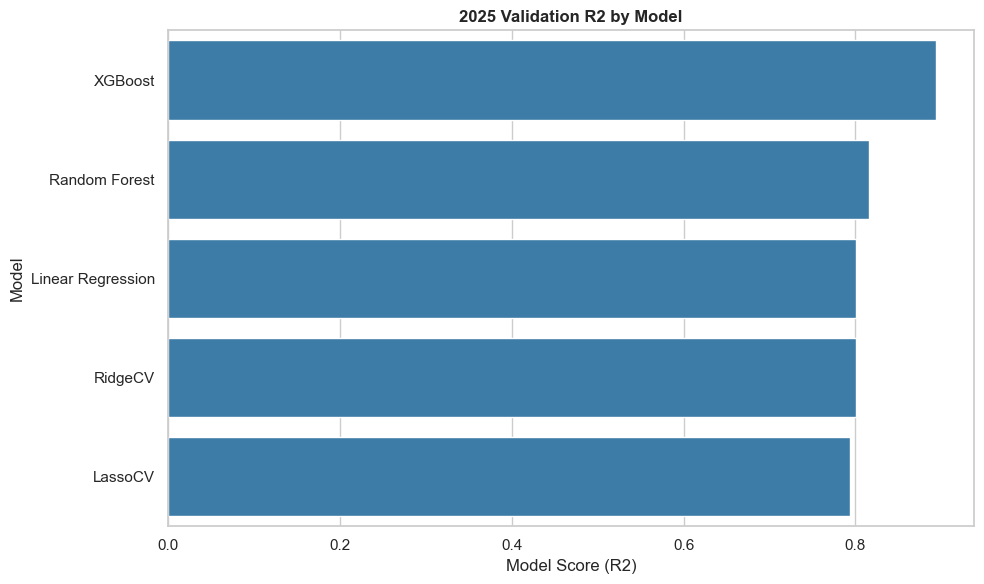

In [62]:
r2_plot = validation_results_df.sort_values("R2").reset_index()
ax = sns.barplot(data=r2_plot, x="R2", y="Model", color=PRIMARY_COLOR)
ax.set(
    title="2025 Validation R2 by Model",
    xlabel="Model Score (R2)",
    ylabel="Model",
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [63]:
best_validation_model_name = validation_results_df.index[0]
best_validation_mae = validation_results_df.iloc[0]["MAE"]
best_validation_r2 = validation_results_df.iloc[0]["R2"]

extra = ""
if best_validation_model_name == "XGBoost":
    extra = (
        f" XGBoost stopped at boosting iteration "
        f"{fitted_models['XGBoost'].best_iteration}."
    )

display(
    Markdown(
        f"""
**Validation selection:** `{best_validation_model_name}` achieved the lowest 2025 MAE at approximately **S${best_validation_mae:,.0f}**, with **R² = {best_validation_r2:.3f}**.{extra}

This model is selected using validation data only. The 2026 test target has not been used for model selection or early stopping.
"""
    )
)


**Validation selection:** `LassoCV` achieved the lowest 2025 MAE at approximately **S$64,511**, with **R² = 0.794**.

This model is selected using validation data only. The 2026 test target has not been used for model selection or early stopping.


## 15. Validation diagnostics for the selected model

In [64]:
best_validation_prediction = validation_predictions[best_validation_model_name]
validation_residuals = y_validation.to_numpy() - best_validation_prediction

validation_diagnostics = pd.DataFrame(
    {
        "actual": y_validation.to_numpy(),
        "predicted": best_validation_prediction,
        "residual": validation_residuals,
        "absolute_error": np.abs(validation_residuals),
    }
)
validation_diagnostics.describe()

,actual,predicted,residual,absolute_error
count,"25,072.00","25,072.00","25,072.00","25,072.00"
mean,"652,509.23","620,714.35","31,794.88","64,510.67"
std,"204,063.31","150,140.29","86,922.71","66,368.06"
min,"250,000.00","170,507.35","-313,772.91",3.02
25%,"510,000.00","517,162.10","-19,484.41","20,847.56"
50%,"628,000.00","614,651.32","21,778.91","44,618.13"
75%,"760,000.00","713,269.66","66,984.09","83,626.52"
max,"1,658,888.00","1,271,387.99","573,992.40","573,992.40"


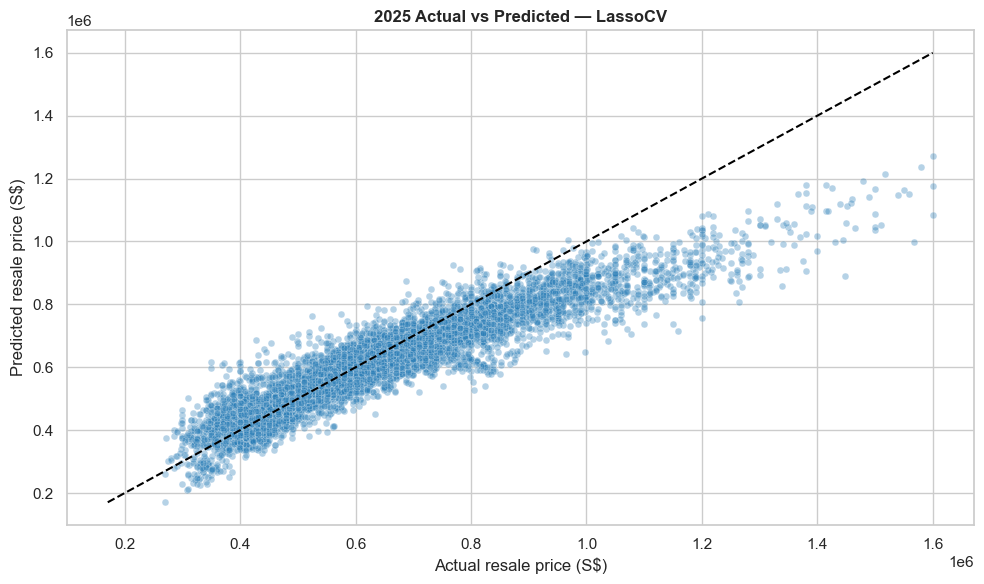

In [65]:
validation_plot_sample = validation_diagnostics.sample(
    n=min(8_000, len(validation_diagnostics)),
    random_state=RANDOM_STATE,
)

ax = sns.scatterplot(
    color=PRIMARY_COLOR,
    data=validation_plot_sample,
    x="actual",
    y="predicted",
    alpha=0.35,
    s=24,
)
plot_min = min(validation_plot_sample["actual"].min(), validation_plot_sample["predicted"].min())
plot_max = max(validation_plot_sample["actual"].max(), validation_plot_sample["predicted"].max())
ax.plot([plot_min, plot_max], [plot_min, plot_max], linestyle="--", color="black")
ax.set(
    title=f"2025 Actual vs Predicted — {best_validation_model_name}",
    xlabel="Actual resale price (S$)",
    ylabel="Predicted resale price (S$)",
)
plt.tight_layout()
plt.show()

In [66]:
validation_diagnostics["actual_price_band"] = pd.qcut(
    validation_diagnostics["actual"],
    q=5,
    duplicates="drop",
)
error_by_band = (
    validation_diagnostics.groupby("actual_price_band", observed=True)
    .agg(
        transactions=("actual", "size"),
        mean_actual=("actual", "mean"),
        MAE=("absolute_error", "mean"),
    )
)
error_by_band

,transactions,mean_actual,MAE
actual_price_band,,,
"(249999.999, 480000.0]",5161,"407,341.94","53,808.31"
"(480000.0, 581655.2]",4868,"535,517.49","35,119.65"
"(581655.2, 670000.0]",5151,"628,120.13","36,197.43"
"(670000.0, 802000.0]",4884,"730,730.81","53,797.49"
"(802000.0, 1658888.0]",5008,"967,688.58","143,679.03"


Residual diagnostics reveal whether errors are centred around zero and whether prediction quality changes across the price distribution. Housing models often have larger dollar errors for premium properties, so both MAE and error by price band should be examined rather than relying only on overall R².

# 16. Refit the selected model on 2017-2025 data

In [67]:
# Combine training and validation only after model selection.
train_validation_mask = model_df["transaction_year"].between(2017, 2025)
X_train_validation = X.loc[train_validation_mask].copy()
y_train_validation = y.loc[train_validation_mask].copy()

final_preprocessor = make_preprocessor()
X_train_validation_prepared = final_preprocessor.fit_transform(X_train_validation)
X_test_final_prepared = final_preprocessor.transform(X_test)
final_feature_names = final_preprocessor.get_feature_names_out()

selected_rounds = int(fitted_models["XGBoost"].best_iteration) + 1
final_model = XGBRegressor(
    n_estimators=selected_rounds,
    learning_rate=0.08,
    max_depth=6,
    min_child_weight=3,
    subsample=0.90,
    colsample_bytree=0.90,
    reg_lambda=2.0,
    objective="reg:squarederror",
    eval_metric="mae",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

final_started = time.perf_counter()
final_model.fit(X_train_validation_prepared, y_train_validation)
test_prediction = final_model.predict(X_test_final_prepared)
final_elapsed = time.perf_counter() - final_started

final_test_metrics = regression_metrics(y_test, test_prediction)
final_test_metrics["Fit_and_predict_seconds"] = final_elapsed
pd.Series(final_test_metrics, name="2026 test result")

MAE                       39,563.74
RMSE                      56,492.75
R2                             0.93
MAPE_percent                   5.90
Fit_and_predict_seconds        0.78
Name: 2026 test result, dtype: float64

# 17. Final Test Prediciton Results (2026)

In [68]:
test_mae = final_test_metrics["MAE"]
test_rmse = final_test_metrics["RMSE"]
test_r2 = final_test_metrics["R2"]
test_mape = final_test_metrics["MAPE_percent"]
test_bias = float(np.mean(test_prediction - y_test.to_numpy()))

final_summary = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R²", "MAPE", "Mean prediction bias"],
        "2026 test value": [
            f"S${test_mae:,.0f}",
            f"S${test_rmse:,.0f}",
            f"{test_r2:.3f}",
            f"{test_mape:.2f}%",
            f"S${test_bias:,.0f}",
        ],
    }
)
final_summary

,Metric,2026 test value
0,MAE,"S$39,564"
1,RMSE,"S$56,493"
2,R²,0.930
3,MAPE,5.90%
4,Mean prediction bias,"S$-4,006"


In [69]:
display(
    Markdown(
        f"""
The final `{best_validation_model_name}` model was refitted on **2017–2025** and evaluated once on the untouched **January–August 2026** test set.

- Average absolute error: **S${test_mae:,.0f}**
- Root mean squared error: **S${test_rmse:,.0f}**
- Explained variance: **R² = {test_r2:.3f}**
- Average percentage error: **{test_mape:.2f}%**
- Mean prediction bias: **S${test_bias:,.0f}**

The test result should be interpreted as performance on the available partial-year 2026 transactions, not as a guarantee for later market conditions.
"""
    )
)


The final `LassoCV` model was refitted on **2017–2025** and evaluated once on the untouched **January–August 2026** test set.

- Average absolute error: **S$39,564**
- Root mean squared error: **S$56,493**
- Explained variance: **R² = 0.930**
- Average percentage error: **5.90%**
- Mean prediction bias: **S$-4,006**

The test result should be interpreted as performance on the available partial-year 2026 transactions, not as a guarantee for later market conditions.


# 18. Feature Importance for the final model

In [70]:
def original_feature_from_transformed_name(transformed_name):
    if transformed_name.startswith("num__"):
        return transformed_name.split("__", 1)[1]

    if transformed_name.startswith("cat__"):
        encoded_name = transformed_name.split("__", 1)[1]
        for column in categorical_features:
            if encoded_name.startswith(f"{column}_"):
                return column

    return transformed_name


if hasattr(final_model, "feature_importances_"):
    raw_importance = np.asarray(final_model.feature_importances_)
elif hasattr(final_model, "coef_"):
    raw_importance = np.abs(np.asarray(final_model.coef_).ravel())
else:
    raw_importance = None

if raw_importance is not None:
    transformed_importance = (
        pd.DataFrame(
            {
                "transformed_feature": final_feature_names,
                "importance": raw_importance,
            }
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    transformed_importance["original_feature"] = transformed_importance[
        "transformed_feature"
    ].map(original_feature_from_transformed_name)

    grouped_importance = (
        transformed_importance.groupby("original_feature", as_index=False)["importance"]
        .sum()
        .sort_values(by="importance", ascending=False)
    )

    display(grouped_importance)
else:
    print("The selected model does not expose native feature importance values.")

,original_feature,importance
5,town,0.58
1,flat_type,0.17
0,flat_model,0.13
7,transaction_year,0.04
2,floor_area_sqm,0.04
4,storey_midpoint,0.03
3,remaining_lease_years,0.01
6,transaction_month,0.00


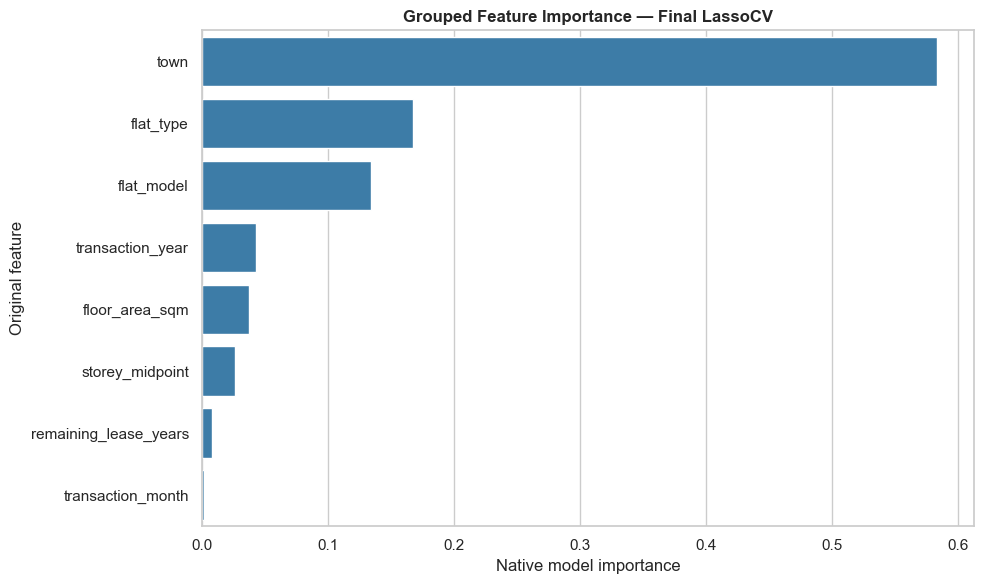

In [71]:
if raw_importance is not None:
    ax = sns.barplot(
        color=PRIMARY_COLOR,
        data=grouped_importance,
        x="importance",
        y="original_feature",
    )
    ax.set(
        title=f"Grouped Feature Importance — Final {best_validation_model_name}",
        xlabel="Native model importance",
        ylabel="Original feature",
    )
    plt.tight_layout()
    plt.show()

Native tree importance shows which variables the fitted model used most often or most effectively for prediction. It is **not causal evidence**. Correlated features can divide importance between them, and one-hot categories can spread a variable's influence across multiple encoded columns. Permutation importance or SHAP values are useful extensions for deeper interpretation.

# 19. Export of the ML-ready data and fitted model

In [ ]:
# Set to True when you want files written beside the notebook.
SAVE_ARTIFACTS = False

if SAVE_ARTIFACTS:
    output_dir = Path("hdb_model_outputs")
    output_dir.mkdir(exist_ok=True)

    # Clean modelling table, including the date used for temporal splitting.
    model_df.to_csv(output_dir / "hdb_ml_ready.csv", index=False)

    # Save the final preprocessor and model together with metadata.
    model_bundle = {
        "features": features,
        "categorical_features": categorical_features,
        "numeric_features": numeric_features,
        "preprocessor": final_preprocessor,
        "model": final_model,
        "selected_model_name": best_validation_model_name,
        "test_metrics": final_test_metrics,
    }
    joblib.dump(model_bundle, output_dir / "hdb_resale_price_model.joblib")

    validation_results_df.to_csv(output_dir / "validation_model_comparison.csv")

    print(f"Saved outputs to: {output_dir.resolve()}")
else:
    print("SAVE_ARTIFACTS is False; no external files were written.")

Saved outputs to: /Users/admin/Desktop/IOD/Mini Project 2/hdb_model_outputs


# 20. Final conclusions

## EDA

- Resale prices show a strong market-time trend, especially after 2020.
- Floor area, town, flat type, storey, flat model, and remaining lease all contain predictive information.
- Price is shaped by interactions: the same flat type has different typical values across towns.
- Premium transactions are statistical outliers but appear plausible and are retained.
- `price_per_sqm` is excluded from modelling because it directly contains the target.

## Machine learning

- A temporal split provides a realistic future-prediction test.
- Linear Regression supplies an interpretable additive benchmark.
- Random Forest improves on linear modelling by learning nonlinearities and interactions.
- XGBoost is expected to perform best on this feature set because it sequentially learns complex residual patterns.
- The chosen model is selected on 2025 only, refitted on 2017–2025, and evaluated once on the partial-year 2026 test set.

## Recommended extensions

1. Add MRT distance, CBD distance, latitude/longitude, or planning-area data.
2. Test `street_name` using leakage-safe target encoding or hashing rather than unrestricted one-hot encoding.
3. Compare raw-price and log-price targets.
4. Tune hyperparameters using rolling or expanding-window validation.
5. Monitor performance over time because housing-market relationships can drift.